# Image Classification with a Convolutional Neural Network

A convolutional neural network (CNN) that classifies images into two classes (dogs vs. carp). The network is a small, Xception-inspired architecture built from scratch in **Keras / TensorFlow**.

**Techniques:** image loading & cleaning, data augmentation, CNN design (Conv2D / BatchNorm / MaxPooling / Dropout), training and inference on new images.

### 1. Imports

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.preprocessing.image import load_img, ImageDataGenerator

### 2. Load the image data
The dataset is a folder with two sub-folders, one per class, each containing the images.

In [ ]:
import zipfile

# Replace "your_data.zip" with the actual filename
with zipfile.ZipFile("pets.zip", 'r') as zip_ref:
    zip_ref.extractall("petsimage")

!unzip -q pets.zip
!ls

cane  carpa  petsimage	pets.zip  sample_data


In [ ]:
import os

num_skipped = 0
for folder_name in ("cane", "carpa"):
    folder_path = os.path.join("petsimage", folder_name)
    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)
        try:
            fobj = open(fpath, "rb")
            is_jfif = tf.compat.as_bytes("JFIF") in fobj.peek(10)
        finally:
            fobj.close()

        if not is_jfif:
            num_skipped += 1
            # Delete corrupted image
            os.remove(fpath)

print("Deleted %d images" % num_skipped)

Deleted 0 images


### 3. Build the training and validation sets (with data augmentation)
We apply light augmentation (rotation, zoom, shifts, horizontal flip) so the model sees more variation and overfits less, and hold out 20% of the images for validation.

In [ ]:
image_size = (180, 180)

datagen = ImageDataGenerator( rescale=1./255,
        rotation_range=3,  # randomly rotate images in the range (degrees, 0 to 180)
        zoom_range = 0.01, # Randomly zoom image
        width_shift_range=0.01,  # randomly shift images horizontally (fraction of total width)
        height_shift_range=0.01,  # randomly shift images vertically (fraction of total height)
        horizontal_flip=True,  # randomly flip images
        validation_split=0.2)  # validation split
train_ds = datagen.flow_from_directory(
        "petsimage", target_size=image_size, color_mode='rgb', class_mode='categorical',
         batch_size=64, shuffle=True, seed=13,
        subset='training')
val_ds = datagen.flow_from_directory(
        "petsimage", target_size=image_size, color_mode='rgb', class_mode='categorical',
         batch_size=64, seed=13,
        subset='validation')

Found 1981 images belonging to 2 classes.
Found 494 images belonging to 2 classes.


### 4. Preview a batch
A quick look at some augmented images and their labels (0 = dog, 1 = carp).

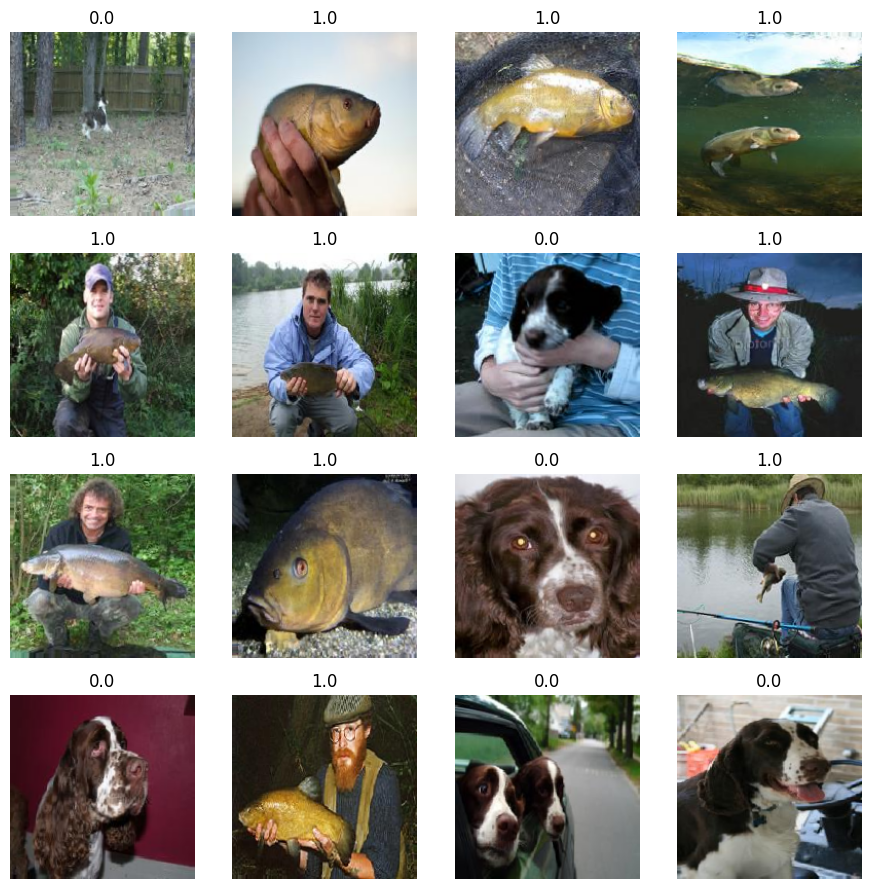

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 11))
images=train_ds[0][0]
labels=train_ds[0][1]
for i in range(16):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(images[i].astype("float32"))
#        print(i,labels[i][1])
        plt.title(labels[i][1])
        plt.axis("off")

### 5. Model architecture
A stack of convolutional blocks (Conv2D + BatchNorm + MaxPooling + Dropout) followed by a dense head with a softmax output over the two classes.

In [ ]:
from tensorflow.keras.layers import InputLayer, Input, BatchNormalization
from tensorflow.keras.layers import Reshape, MaxPooling2D
from tensorflow.keras.layers import Conv2D, Dense, Flatten, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.utils import plot_model

inp = Input((180,180,3))
x = Conv2D(32,(5,5),activation='relu',input_shape=(180,180,3))(inp)
x = BatchNormalization()(x)
x = MaxPooling2D()(x)
x = Dropout(0.2)(x)
x = Conv2D(32,(3,3),activation='relu')(x)
x = BatchNormalization()(x)
x = MaxPooling2D()(x)
x = Dropout(0.2)(x)
x = Conv2D(16,(3,3),activation='relu')(x)
x = BatchNormalization()(x)
x = MaxPooling2D()(x)
x = Dropout(0.2)(x)
x = Flatten()(x)
x= Dense(128,activation='relu')(x)
x= BatchNormalization()(x)
x = Dropout(0.3)(x)
out = Dense(2,activation='softmax')(x)
model = Model(inp,out)
model.compile(loss='categorical_crossentropy', optimizer='adam',metrics=['accuracy'])

model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 180, 180, 3)]     0         
                                                                 
 conv2d (Conv2D)             (None, 176, 176, 32)      2432      
                                                                 
 batch_normalization (Batch  (None, 176, 176, 32)      128       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 88, 88, 32)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 88, 88, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 86, 86, 32)        9248  

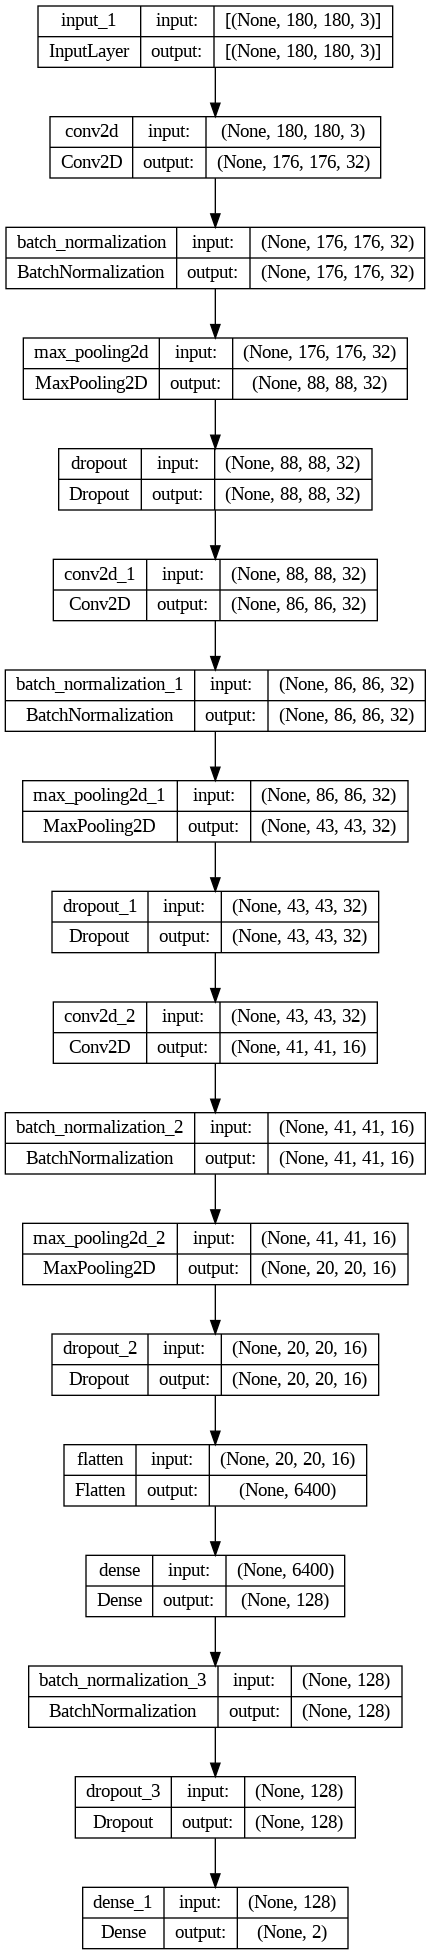

In [ ]:
plot_model(model, show_shapes=True)

*Alternative approach: the same architecture could be searched automatically with Keras Tuner.*

### 6. Train the model

In [ ]:
history = model.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10
31/31 [==============================] - 168s 5s/step - loss: 0.5821 - accuracy: 0.7860 - val_loss: 0.8277 - val_accuracy: 0.5202
Epoch 2/10
31/31 [==============================] - 145s 5s/step - loss: 0.3208 - accuracy: 0.8713 - val_loss: 2.1683 - val_accuracy: 0.5081
Epoch 3/10
31/31 [==============================] - 148s 5s/step - loss: 0.2413 - accuracy: 0.9031 - val_loss: 2.3001 - val_accuracy: 0.5081
Epoch 4/10
31/31 [==============================] - 154s 5s/step - loss: 0.2014 - accuracy: 0.9182 - val_loss: 2.5045 - val_accuracy: 0.5121
Epoch 5/10
31/31 [==============================] - 147s 5s/step - loss: 0.2215 - accuracy: 0.9096 - val_loss: 1.0376 - val_accuracy: 0.5769
Epoch 6/10
31/31 [==============================] - 154s 5s/step - loss: 0.1817 - accuracy: 0.9298 - val_loss: 1.5635 - val_accuracy: 0.5364
Epoch 7/10
31/31 [==============================] - 146s 5s/step - loss: 0.1601 - accuracy: 0.9419 - val_loss: 1.2583 - val_accuracy: 0.5810
Epoch 8/10
31

### 7. Inference on a new image
Augmentation is only used at training time; at inference we simply rescale the input image and predict.

In [ ]:
import numpy as np
img = load_img('cane.JPEG', target_size=(180,180))
A = keras.preprocessing.image.img_to_array(img)/255.
B = A.reshape(1,180,180,3)
my_prediction = model.predict(B)
np.set_printoptions(suppress=True,precision=4)
print("Your algorithm predicts",  my_prediction)